# Tatoeba Language Detection Dataset - Exploratory Data Analysis (EDA)

This notebook explores the dataset from the Tatoeba project, focusing on the 10 most popular languages. The goal is to perform statistical and visual analysis such as language distribution and sentence length characteristics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading

We load the training and validation (dev) datasets. Based on our preliminary inspection, the files are tab-separated and do not contain headers. The first column is the 3-letter language code and the second column is the text.

In [2]:
data_dir = "tatoeba"
train_file = os.path.join(data_dir, "sentences.top10langs.train.tsv")
dev_file = os.path.join(data_dir, "sentences.top10langs.dev.tsv")

# Read the files
train_df = pd.read_csv(train_file, sep='\t', header=None, names=['lang', 'text'])
dev_df = pd.read_csv(dev_file, sep='\t', header=None, names=['lang', 'text'])

print(f"Train set: {len(train_df)} rows")
print(f"Dev set: {len(dev_df)} rows")

train_df.head()

Train set: 99863 rows
Dev set: 10000 rows


,lang,text
0,spa,"Te di mi corazón para que lo ames, ¡no para us..."
1,spa,Contamos con tu ayuda.
2,spa,Tú eres superficial y materialista.
3,spa,Los límites son para los demás.
4,spa,Todos ellos esperaron ansiosamente las vacacio...


## 2. Statistical Analysis - Language Distribution

We check if the dataset is balanced across the 10 languages.

In [3]:
print("Language Distribution (Train):")
print(train_df['lang'].value_counts())

print("\nLanguage Distribution (Dev):")
print(dev_df['lang'].value_counts())

Language Distribution (Train):
lang
spa    10000
deu    10000
tur    10000
fra    10000
epo    10000
ita    10000
hun    10000
ber    10000
eng    10000
por     9863
Name: count, dtype: int64

Language Distribution (Dev):
lang
por    1000
tur    1000
ber    1000
eng    1000
hun    1000
epo    1000
fra    1000
deu    1000
ita    1000
spa    1000
Name: count, dtype: int64


## 3. Sentence Length Analysis

We compute the length of sentences in terms of characters and word counts for each language.

In [4]:
# Pre-calculate lengths
train_df['char_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

stats = train_df.groupby('lang').agg({
    'char_length': ['mean', 'median', 'std', 'max', 'min'],
    'word_count': ['mean', 'median', 'std', 'max', 'min']
})

print("Sentence Statistics by Language (Train):")
stats

Sentence Statistics by Language (Train):


char_length                             word_count                    \
            mean median        std   max min       mean median        std   
lang                                                                        
ber    30.940700   28.0  15.003289   257   3   4.981600    4.0   2.694362   
deu    48.143200   40.0  32.740847   690   3   8.004200    7.0   5.067736   
eng    38.549300   35.0  20.840965   437   3   7.600400    7.0   3.926737   
epo    39.973000   34.0  26.066956   412   3   7.046200    6.0   4.456125   
fra    42.335500   36.0  30.632557   597   4   7.690600    7.0   5.290980   
hun    33.761700   30.0  19.660096   361   5   5.257900    5.0   2.951959   
ita    33.272100   30.0  18.027844   425   3   5.844600    5.0   3.063036   
por    38.053331   32.0  63.540638  5833   5   6.979215    6.0  11.649519   
spa    38.587700   33.0  25.008903   576   5   7.009900    6.0   4.386699   
tur    34.469100   32.0  15.063769   313   3   4.985600    5.0   2.111738   

                
       max min  
lang            
ber     42   1  
deu    107   1  
eng     92   1  
epo     74   1  
fra    105   1  
hun     52   1  
ita     68   1  
por   1078   1  
spa     96   1  
tur     41   1

## 4. Visualizations

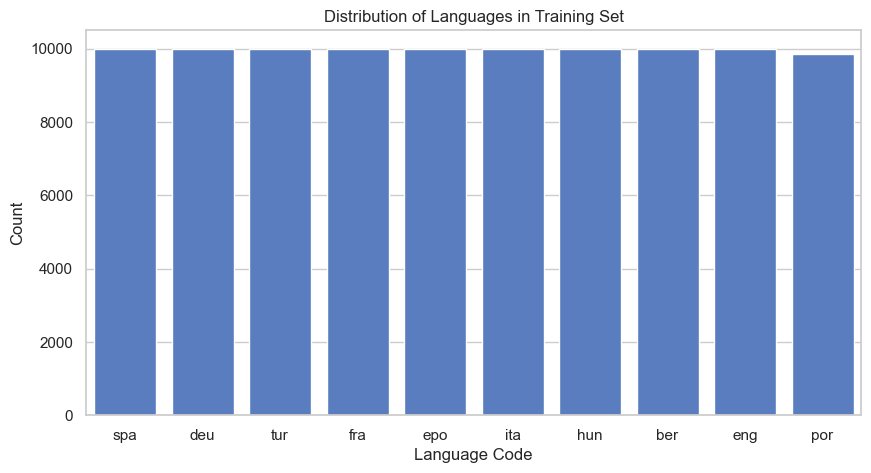

In [5]:
# Plot Language Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='lang', data=train_df, order=train_df['lang'].value_counts().index)
plt.title("Distribution of Languages in Training Set")
plt.xlabel("Language Code")
plt.ylabel("Count")
plt.show()

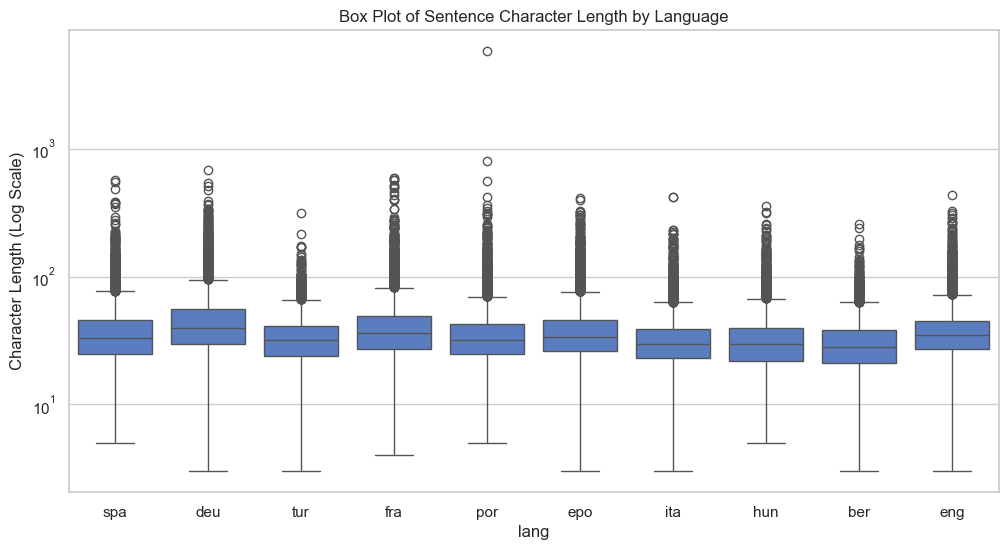

In [6]:
# Box plot for sentence length (characters) per language
plt.figure(figsize=(12, 6))
sns.boxplot(x='lang', y='char_length', data=train_df)
plt.title("Box Plot of Sentence Character Length by Language")
plt.yscale('log') # Log scale for better visibility of distributions
plt.ylabel("Character Length (Log Scale)")
plt.show()

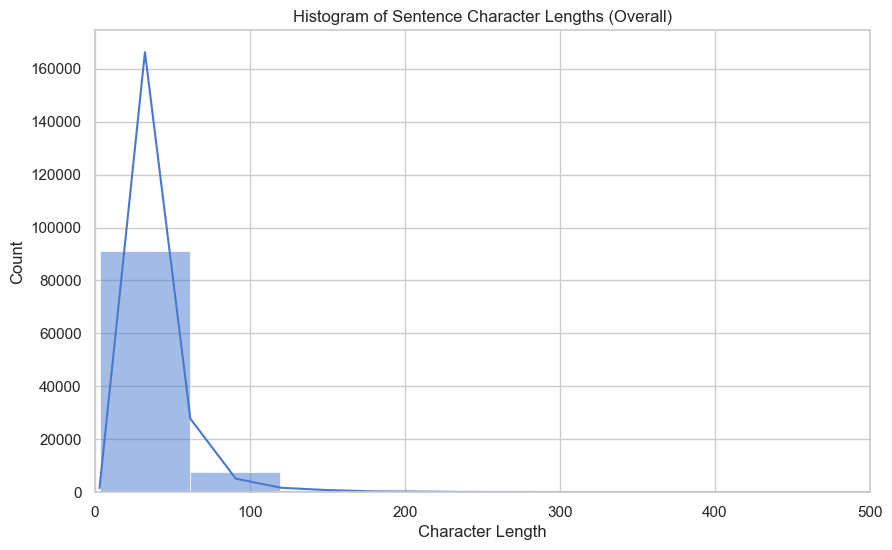

In [7]:
# Histogram of character lengths across the dataset
plt.figure(figsize=(10, 6))
sns.histplot(train_df['char_length'], bins=100, kde=True)
plt.title("Histogram of Sentence Character Lengths (Overall)")
plt.xlim(0, 500) # Capping for visibility of the main bulk
plt.xlabel("Character Length")
plt.show()